In [1]:
from pyspectrum.core.spectrum import Spectrum
from pyspectrum.core.domain import Domain
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.convolution import Convolution
from pyspectrum.calibration import AxisCalibration,ResolutionCalibration
from pyspectrum.calibration.detector_calibration import DetectorCalibration
from pyspectrum.calibration.models import PolynomialEnergyModel, StandardHPGeFWHMModel
from pyspectrum.background.snip import SNIPBackground
#from pyspectrum.io.time_channel import TimeChannelParser
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum = Spectrum(spectrum['counts'].values)
spectrum

<xarray.DataArray (channel: 8192)>
array([0, 0, 0, ..., 3, 4, 3], dtype=int64)
Coordinates:
  * channel  (channel) int32 0 1 2 3 4 5 6 ... 8186 8187 8188 8189 8190 8191

In [3]:
# calibration

In [4]:
domains = [(383, 403), (1140,1165), (1485, 1505), (2627, 2650), (3260,3285), (4770, 4810)]
energies = [121.78, 344.28, 443.96, 778.9, 964.08, 1408]

calib = DetectorCalibration(spectrum=spectrum,
                            known_axis_values=energies,
                            peak_domains=domains,
                            energy_model=PolynomialEnergyModel(degree=2),
                            fwhm_model=StandardHPGeFWHMModel())
energy_calibration, resolution_calibration = calib.generate([0, 1,0], [0, 0.02,0])

In [5]:
peaks_center_ch, peaks_fwhm_ch = calib.estimate_peaks()
fwhm_val = (energy_calibration.apply(peaks_center_ch+peaks_fwhm_ch/2) - energy_calibration.apply(peaks_center_ch-peaks_fwhm_ch/2))

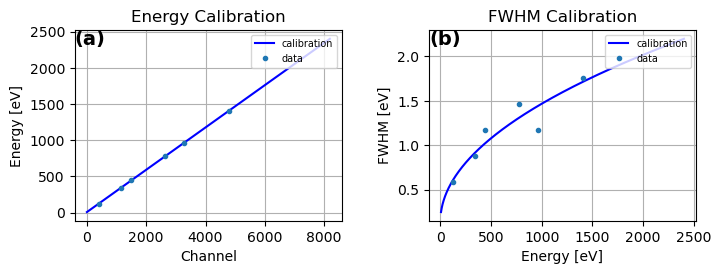

In [6]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, energy_calibration.apply(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, energy_calibration.apply(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [eV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===

ax2.plot(energy_calibration.apply(spectrum.channels), resolution_calibration.func(energy_calibration.apply(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [eV]')
ax2.set_ylabel('FWHM [eV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()


In [7]:
spectrum.set_axis_calibration(energy_calibration)
spectrum.set_resolution_calibration(resolution_calibration)

In [8]:
# find peaks

In [9]:
conv = Convolution(width=spectrum.resolution_calib)

In [10]:
finder = SNRFinder(conv, n_sigma_threshold=5, extension_factor=0.5)

In [11]:
peaks = finder.find(spectrum=spectrum)

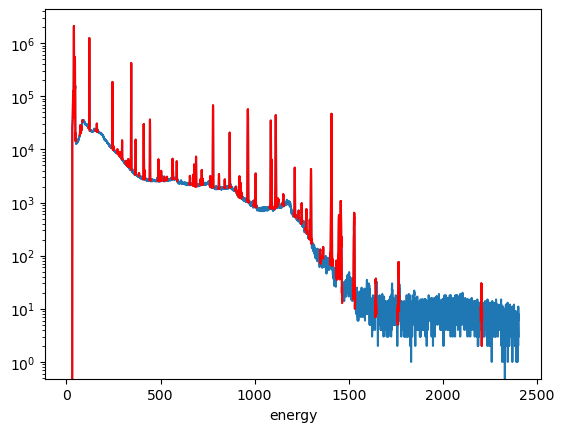

In [12]:
spectrum.plot(yscale='log')
for peak in peaks:
    spectrum[peak.indices].plot(color='red')

In [25]:
spectrum.counts[:np.where(spectrum.counts>0)[0][0]] = spectrum.counts[np.where(spectrum.counts>0)[0][0]]
background_est = SNIPBackground(iterations=30)
bg = background_est.estimate(spectrum)

In [26]:
spectrum

<xarray.DataArray (energy: 8192)>
array([19919, 19919, 19919, ...,     3,     4,     3], dtype=int64)
Coordinates:
  * energy   (energy) float64 6.696 6.989 7.282 ... 2.401e+03 2.402e+03

(1.0, 10000000.0)

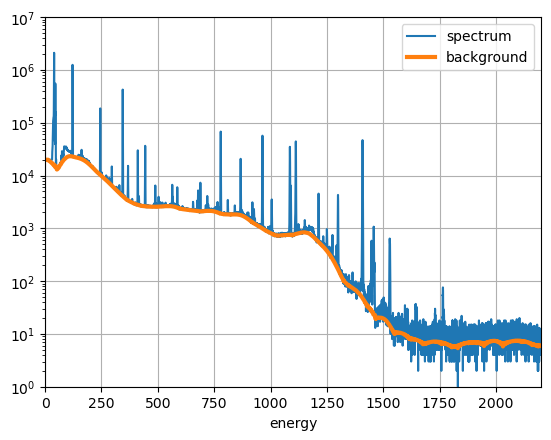

In [27]:
spectrum.plot(yscale='log', label='spectrum')
bg.plot(linewidth=3, label='background')
plt.xlim([0,2200])

plt.grid()
plt.legend()
plt.ylim([1e0,1e7])